# Open Notebook & Additional Resources

<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ORM_AI_Agents_Bootcamp/blob/main/hands_on/DAY_1_HANDS_ON_SESSION_4_hierarchical_agent_teams.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
<a target="_blank" href="https://learning.oreilly.com/library/view/ai-agents-the/0642572247775/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="AI Agents Book – Read on O'Reilly"/>
</a>





<font color="red" size="10">
<b>HANDS-ON TIME: 15 mins</b>
</font>

# About this Notebook

## From Single Agent to Hierarchical Agent Teams


- the original single-agent baseline
- a **lead agent** that decides when to delegate
- two imported specialist skills loaded from Google Drive
- a consulting report specialist and a frontend implementation specialist
- a final synthesis step that assembles both outputs into one handoff

This example produces a real report and real generated frontend files.

# Visual Overview

## Baseline: single agent

```mermaid
flowchart LR
    U[User Request] --> A[Single Agent]
    A --> T[Search Tool]
    T --> A
    A --> R[Final Response]
```

## Refactor: hierarchical workflow

```mermaid
flowchart LR
    U[User Request] --> L[Lead Agent]
    L --> P{Simple or Complex?}
    P -->|Simple| D[Direct Answer]
    P -->|Complex| C[Consulting Report Specialist]
    C --> F[Frontend Implementation Specialist]
    F --> S[Final Synthesis]
    S --> R[Final Response]
```

The point of the refactor is not that multi-agent is always better. It is that delegation can make larger tasks easier to reason about while keeping specialist outputs explicit.

# Dependencies

In [ ]:
!pip install -q \
    langchain==0.3.27 \
    langgraph==0.6.7 \
    langchain-openai==0.3.33 \
    langchain_experimental==0.3.4 \
    openai \
    python-dotenv==1.1.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.9/458.9 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently tak

# API Setup

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    print("OPENAI_API_KEY not found.")
    OPENAI_API_KEY = input("Enter OPENAI_API_KEY: ").strip()
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

print("OPENAI_API_KEY is set.")

OPENAI_API_KEY is set.


# Imports

In [ ]:
import os
import re
import json
import shutil
import urllib.request
from pathlib import Path
from typing import Annotated, TypedDict

from IPython.display import Code, HTML, Markdown, display
from openai import OpenAI
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, create_react_agent
from langgraph.checkpoint.memory import MemorySaver

# Part 1: Existing single-agent workflow

The baseline below gives one agent too many responsibilities:

- understand the task
- decide what to research
- run searches
- synthesize the findings
- write the final artifact

That can work for small prompts, but it becomes harder to debug and harder to scale once the request becomes more complex.

In [ ]:
def _obj_get(x, key, default=None):
    if isinstance(x, dict):
        return x.get(key, default)
    return getattr(x, key, default)


@tool("internet_search")
def internet_search(query: str) -> dict:
    """Run OpenAI web search and return a compact answer with sources."""
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

    response = client.responses.create(
        model="gpt-5",
        tools=[{"type": "web_search"}],
        include=["web_search_call.action.sources"],
        input=query,
    )

    output_text = _obj_get(response, "output_text", "") or ""
    sources = []

    for item in _obj_get(response, "output", []) or []:
        if _obj_get(item, "type") == "web_search_call":
            action = _obj_get(item, "action")
            for src in _obj_get(action, "sources", []) or []:
                sources.append(
                    {
                        "title": _obj_get(src, "title"),
                        "url": _obj_get(src, "url"),
                    }
                )

    return {
        "query": query,
        "answer": output_text,
        "sources": sources,
    }


class SingleAgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


single_llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0).bind_tools([internet_search])

SINGLE_AGENT_SYSTEM = """
You are one agent responsible for the full task.

You may use the `internet_search` tool when helpful.
You must handle planning, research, synthesis, and writing yourself.
Try to produce a concise but useful answer with source URLs when available.
""".strip()


def single_agent_node(state: SingleAgentState) -> SingleAgentState:
    msgs = [SystemMessage(content=SINGLE_AGENT_SYSTEM), *state["messages"]]
    ai = single_llm.invoke(msgs)
    return {"messages": [ai]}


def route_after_single_agent(state: SingleAgentState):
    last = state["messages"][-1]
    calls = getattr(last, "tool_calls", None) or []
    return "tools" if calls else END


single_agent_graph = StateGraph(SingleAgentState)
single_agent_graph.add_node("agent", single_agent_node)
single_agent_graph.add_node("tools", ToolNode([internet_search]))
single_agent_graph.add_edge(START, "agent")
single_agent_graph.add_conditional_edges(
    "agent",
    route_after_single_agent,
    {"tools": "tools", END: END},
)
single_agent_graph.add_edge("tools", "agent")

single_agent_app = single_agent_graph.compile(checkpointer=MemorySaver())

In [ ]:
single_agent_prompt = """
Create a short strategy brief for launching an AI study assistant.

You need to:
1. Identify recent market signals or competitor moves.
2. Summarize the main user pain points.
3. Recommend a positioning angle.
4. Draft a short executive summary.

Keep the final answer structured and include source URLs.
""".strip()

single_config = {
    "configurable": {"thread_id": "single-agent-baseline"},
    "recursion_limit": 8,
}

single_result = single_agent_app.invoke(
    {"messages": [HumanMessage(content=single_agent_prompt)]},
    config=single_config,
)

print(single_result["messages"][-1].content)

## AI Study Assistant Launch Strategy Brief

### 1) Recent market signals / competitor moves
- **Google is pushing AI study tooling into education at scale.** Gemini for Education is now a core Workspace offering for institutions, and NotebookLM is adding study features like **flashcards, quizzes, and reports**. This signals rising expectations for embedded, low-friction study workflows.  
  Sources:  
  https://edu.google.com/intl/all_us/ai/gemini-for-education  
  https://workspaceupdates.googleblog.com/2025/09/flashcards-quizzes-reports-notebook-lm-google-education.html
- **Quizlet is doubling down on AI-generated study materials.** Its AI study tools continue to center on turning notes into flashcards, quizzes, and study guides, reinforcing the “upload → practice” pattern.  
  Source: https://quizlet.com/features/ai-study-tools
- **Chegg is repositioning around personalized AI learning.** Chegg launched new AI-powered “Create” functionality and has publicly shifted from Q&A toward 

# Part 2: Multi-agent

This version uses a more defined path instead of fully dynamic delegation:

- the **lead agent** decides whether to answer directly or use the specialist path
- a **consulting report specialist** loads its skill from Google Drive and writes a real report
- a **frontend implementation specialist** loads its skill from Google Drive and creates real files
- a final **synthesizer** combines both into one response

Important design choice:

- the frontend specialist does **not** build the page directly from the consulting report structure
- instead, it receives a compact product/UX handoff plus separate learning-platform landing-page research
- only selected insights, such as pain points and trust requirements, flow across

This keeps the two tasks related but still distinct.

# Single Agent vs Multi-Agent

## Single agent strengths

- simpler to build
- fewer moving parts
- good for short or well-bounded tasks

## Single agent weaknesses

- one prompt has to juggle planning, research, reasoning, and writing
- harder to inspect where quality breaks down
- harder to scale when tasks become broader or more open-ended

## Multi-agent strengths

- the lead agent can stay focused on coordination
- specialists can use narrower prompts and clearer responsibilities
- delegation makes complex tasks easier to debug and extend

## Multi-agent tradeoffs

- more orchestration code
- more model calls
- more design choices around routing, limits, and shared context

A useful rule of thumb: start with one agent, then split responsibilities only when the task complexity justifies it.

In [ ]:
class LeadDecision(BaseModel):
    is_complex: bool = Field(
        ..., description="Whether the request needs the specialist pipeline."
    )
    direct_answer: str = Field(
        default="", description="Used only if the request is simple enough to answer directly."
    )
    reason: str = Field(
        default="", description="Short explanation for the routing choice."
    )


class SearchQueries(BaseModel):
    queries: list[str] = Field(
        default_factory=list,
        description="One to three focused web-search queries.",
    )


class FrontendHandoff(BaseModel):
    product_name: str = Field(..., description="Product or brand name to use on the landing page.")
    target_audience: str = Field(..., description="Primary audience for the learning platform.")
    core_value_proposition: str = Field(..., description="Short value proposition for the product.")
    top_pain_points: list[str] = Field(default_factory=list, description="Top user pain points relevant to product UX.")
    trust_requirements: list[str] = Field(default_factory=list, description="Trust-building requirements the UI should communicate.")
    primary_cta: str = Field(..., description="Main call to action for the landing page.")
    secondary_cta: str = Field(default="", description="Optional secondary CTA.")
    ux_notes: list[str] = Field(default_factory=list, description="Landing page UX notes, not report sections.")


class MultiAgentState(TypedDict, total=False):
    messages: Annotated[list[BaseMessage], add_messages]
    request: str
    consulting_report: str
    frontend_handoff: str
    frontend_research: str
    frontend_summary: str
    frontend_files: list[str]
    final_answer: str

In [ ]:
CONSULTING_SKILL_URL = "https://drive.google.com/file/d/1SoYAFow_pF27LpywXZ410-PwoiYf4x-G/view?usp=sharing"
FRONTEND_SKILL_URL = "https://drive.google.com/file/d/1PwGnA-u1l_gs7dFiyclSWwmaf0MRxEPh/view?usp=sharing"


def extract_drive_file_id(url: str) -> str:
    match = re.search(r"/d/([^/]+)", url)
    if not match:
        raise ValueError(f"Could not extract Google Drive file id from: {url}")
    return match.group(1)


def load_drive_markdown(url: str) -> str:
    file_id = extract_drive_file_id(url)
    download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
    with urllib.request.urlopen(download_url) as response:
        text = response.read().decode("utf-8")
    if "<html" in text[:500].lower() or "sign in" in text[:500].lower():
        raise ValueError("Google Drive returned HTML instead of raw Markdown. Make sure the file is shared for download.")
    return text


CONSULTING_SKILL = load_drive_markdown(CONSULTING_SKILL_URL)
FRONTEND_SKILL = load_drive_markdown(FRONTEND_SKILL_URL)

print("Loaded consulting skill characters:", len(CONSULTING_SKILL))
print("Loaded frontend skill characters:", len(FRONTEND_SKILL))

WORKING_DIRECTORY = Path("generated_frontend")
WORKING_DIRECTORY.mkdir(exist_ok=True)

repl = PythonREPL()


def log_step(message: str) -> None:
    print(message, flush=True)


def preview_text(text, limit: int = 160) -> str:
    if not isinstance(text, str):
        text = str(text)
    one_line = " ".join(text.split())
    return one_line[:limit] + ("..." if len(one_line) > limit else "")


def print_agent_event(prefix: str, event: dict) -> None:
    for node_name, payload in event.items():
        messages = payload.get("messages", []) if isinstance(payload, dict) else []
        if not messages:
            log_step(f"[{prefix}:{node_name}] update received")
            continue
        last = messages[-1]
        tool_calls = getattr(last, "tool_calls", None) or []
        if tool_calls:
            names = ", ".join(call.get("name", "tool") for call in tool_calls)
            log_step(f"[{prefix}:{node_name}] tool calls -> {names}")
            continue
        content = getattr(last, "content", "")
        if content:
            log_step(f"[{prefix}:{node_name}] {preview_text(content)}")

@tool("write_project_file")
def write_project_file(path: str, content: str) -> str:
    """Write a file inside the generated_frontend working directory."""
    full_path = WORKING_DIRECTORY / path
    full_path.parent.mkdir(parents=True, exist_ok=True)
    full_path.write_text(content, encoding="utf-8")
    return f"Wrote {full_path}"


@tool("read_project_file")
def read_project_file(path: str) -> str:
    """Read a file from the generated_frontend working directory."""
    full_path = WORKING_DIRECTORY / path
    return full_path.read_text(encoding="utf-8")


@tool("list_project_files")
def list_project_files() -> list[str]:
    """List files inside the generated_frontend working directory."""
    return sorted(
        str(path.relative_to(WORKING_DIRECTORY))
        for path in WORKING_DIRECTORY.rglob("*")
        if path.is_file()
    )


@tool("python_repl_tool")
def python_repl_tool(code: str) -> str:
    """Execute Python code for local project setup, validation, or file inspection."""
    try:
        output = repl.run(code)
    except BaseException as exc:
        return f"Python REPL failed: {exc!r}"
    return output or "Python REPL executed successfully."


lead_llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)
query_llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)
report_llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)
lead_router = lead_llm.with_structured_output(LeadDecision)
frontend_handoff_llm = report_llm.with_structured_output(FrontendHandoff)

frontend_agent = create_react_agent(
    ChatOpenAI(model="gpt-5.4-mini", temperature=0),
    tools=[write_project_file, read_project_file, list_project_files, python_repl_tool],
    prompt=(
        FRONTEND_SKILL
        + "\n\nYou are the frontend implementation specialist inside a hierarchical workflow. "
        + "Create a simple, polished landing page for a learning platform. "
        + "Do not turn consulting-report sections into website sections. "
        + "Use only the frontend handoff and learning-platform UX research provided to you. "
        + "Focus on conversion, clarity, trust, and product UX for a student-facing learning platform. "
        + "You must create `index.html` and may also create `styles.css` and `app.js`. "
        + "Use the tools to write files, verify the file list, and finish with a concise summary of what you created."
    ),
)

LEAD_SYSTEM = """
You are a lead agent.

If the request is simple, answer directly.
If the request is complex, route it into this fixed pipeline:
1. consulting report specialist
2. frontend implementation specialist
3. final synthesizer
""".strip()


def extract_json_object(text: str) -> str:
    text = text.strip()
    if text.startswith("```"):
        parts = text.split("```")
        if len(parts) >= 3:
            text = parts[1]
            if text.startswith("json"):
                text = text[4:]
            text = text.strip()

    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1 or end <= start:
        raise ValueError(f"Could not extract JSON object from: {preview_text(text, 300)}")
    return text[start : end + 1]


def plan_search_queries(system_instruction: str, user_content: str, max_queries: int) -> SearchQueries:
    response = query_llm.invoke(
        [
            SystemMessage(
                content=(
                    system_instruction
                    + " Return ONLY valid JSON matching this schema: "
                    + '{"queries": ["query 1", "query 2"]}'
                    + ". No prose, no markdown fences, no explanation."
                )
            ),
            HumanMessage(content=user_content),
        ]
    )

    raw = response.content if hasattr(response, "content") else str(response)
    try:
        parsed = SearchQueries.model_validate_json(raw)
    except Exception:
        parsed = SearchQueries.model_validate_json(extract_json_object(raw))

    cleaned = [query.strip() for query in parsed.queries if isinstance(query, str) and query.strip()]
    if not cleaned:
        raise ValueError(f"Query planner returned no usable queries: {preview_text(raw, 300)}")
    return SearchQueries(queries=cleaned[:max_queries])


def build_search_context(request: str) -> str:
    log_step("[consulting] planning search queries")
    query_plan = plan_search_queries(
        system_instruction=(
            "Generate one to three focused web-search queries that help a consulting specialist "
            "write a consulting-grade launch report with market signals, competitors, and user pain points."
        ),
        user_content=request,
        max_queries=3,
    )

    findings = []
    for index, query in enumerate(query_plan.queries[:3], start=1):
        log_step(f"[consulting] search {index}: {query}")
        result = internet_search.invoke({"query": query})
        findings.append(result)
        log_step(f"[consulting] search {index} complete")

    return json.dumps(findings, indent=2)


def build_frontend_research_context(request: str, frontend_handoff: FrontendHandoff) -> str:
    log_step("[frontend] planning UX research queries")
    query_plan = plan_search_queries(
        system_instruction=(
            "Generate one or two focused web-search queries about good landing-page UI/UX for learning platforms, "
            "student-facing edtech products, onboarding clarity, trust signals, and conversion best practices."
        ),
        user_content=(
            f"Request: {request}\n"
            f"Product: {frontend_handoff.product_name}\n"
            f"Audience: {frontend_handoff.target_audience}\n"
            f"Value proposition: {frontend_handoff.core_value_proposition}"
        ),
        max_queries=2,
    )

    findings = []
    for index, query in enumerate(query_plan.queries[:2], start=1):
        log_step(f"[frontend] UX search {index}: {query}")
        result = internet_search.invoke({"query": query})
        findings.append(result)
        log_step(f"[frontend] UX search {index} complete")

    return json.dumps(findings, indent=2)


def build_frontend_handoff(consulting_report: str) -> FrontendHandoff:
    log_step("[frontend] extracting product and UX handoff from consulting report")
    return frontend_handoff_llm.invoke(
        [
            SystemMessage(
                content=(
                    "Extract only the minimum product strategy inputs that a frontend designer should use. "
                    "Do not preserve the report structure. Focus on audience, value proposition, pain points, trust signals, CTAs, and UX notes."
                )
            ),
            HumanMessage(content=consulting_report),
        ]
    )

Loaded consulting skill characters: 33333
Loaded frontend skill characters: 7660


In [ ]:
SYNTHESIZER_SYSTEM = """
You are the final synthesizer in a hierarchical agent workflow.
Combine the consulting report and the frontend implementation outcome into one concise handoff.
Preserve source URLs when they are available.
Highlight what was researched, what was built, and what to do next.
""".strip()


def lead_agent_node(state: MultiAgentState) -> MultiAgentState:
    request = state.get("request") or state["messages"][-1].content
    log_step("[lead] deciding whether to use specialist pipeline")

    decision = lead_router.invoke(
        [
            SystemMessage(content=LEAD_SYSTEM),
            HumanMessage(content=request),
        ]
    )
    log_step(f"[lead] is_complex={decision.is_complex} reason={preview_text(decision.reason)}")

    if not decision.is_complex:
        return {
            "request": request,
            "final_answer": decision.direct_answer or "This request looks simple enough to answer directly.",
        }

    return {"request": request}


def consulting_specialist_node(state: MultiAgentState) -> MultiAgentState:
    log_step("[consulting] starting consulting report generation")
    search_context = build_search_context(state["request"])
    log_step("[consulting] drafting consulting report")

    prompt = f"""
Research request:
{state['request']}

External search findings:
{search_context}

Using the imported consulting skill, write a substantial consulting-grade Markdown report.
The report must include these sections:
1. Executive Summary
2. Market Signals and Competitor Moves
3. User Pain Points
4. Positioning Recommendation
5. Product and Launch Implications
6. References

Requirements:
- Use only evidence from the provided search findings.
- Preserve source URLs in the report.
- Be specific and strategic rather than generic.
""".strip()

    result = report_llm.invoke(
        [
            SystemMessage(content=CONSULTING_SKILL),
            HumanMessage(content=prompt),
        ]
    )
    log_step("[consulting] report complete")
    return {"consulting_report": result.content}


def frontend_specialist_node(state: MultiAgentState) -> MultiAgentState:
    log_step("[frontend] preparing working directory")
    if WORKING_DIRECTORY.exists():
        shutil.rmtree(WORKING_DIRECTORY)
    WORKING_DIRECTORY.mkdir(exist_ok=True)

    frontend_handoff = build_frontend_handoff(state["consulting_report"])
    frontend_research = build_frontend_research_context(state["request"], frontend_handoff)

    prompt = f"""
Build a simple, polished landing page for a learning platform.

Original request:
{state['request']}

Frontend handoff:
{frontend_handoff.model_dump_json(indent=2)}

Learning-platform landing-page UX research:
{frontend_research}

Requirements:
- Do not mirror the consulting report structure as webpage sections.
- Use the pain points only as product insight, not as a report-style content layout.
- The page should feel like a clear, student-facing learning platform landing page, with dark/light contrasts for font and background.
- Prioritize hero clarity, trust signals, product workflow, social proof or credibility, and conversion.
- Create a real frontend implementation in the working directory.
- You must create `index.html`.
- You should also create `styles.css` and optionally `app.js`.
- Keep everything local with no build step.
- After writing files, verify the file list and finish with a short build summary.
""".strip()

    log_step("[frontend] starting tool-using frontend agent")
    final_state = None
    for event in frontend_agent.stream(
        {"messages": [HumanMessage(content=prompt)]},
        config={"recursion_limit": 8},
        stream_mode="values",
    ):
        final_state = event
        messages = event.get("messages", []) if isinstance(event, dict) else []
        if messages:
            last = messages[-1]
            tool_calls = getattr(last, "tool_calls", None) or []
            if tool_calls:
                names = ", ".join(call.get("name", "tool") for call in tool_calls)
                log_step(f"[frontend] tool calls -> {names}")
            else:
                content = getattr(last, "content", "")
                if content:
                    log_step(f"[frontend] {preview_text(content)}")

    files = list_project_files.invoke({})
    summary = final_state.get("messages", [])[-1].content if final_state and final_state.get("messages") else ""
    log_step(f"[frontend] files created: {', '.join(files) if files else 'none'}")
    return {
        "frontend_handoff": frontend_handoff.model_dump_json(indent=2),
        "frontend_research": frontend_research,
        "frontend_summary": summary,
        "frontend_files": files,
    }


def synthesizer_node(state: MultiAgentState) -> MultiAgentState:
    log_step("[synthesizer] preparing final handoff")
    prompt = f"""
Original request:
{state['request']}

Consulting report:
{state['consulting_report']}

Frontend handoff:
{state.get('frontend_handoff', '')}

Frontend implementation summary:
{state['frontend_summary']}

Created frontend files:
{json.dumps(state.get('frontend_files', []), indent=2)}

Write a short final handoff with these sections:
1. What the consulting specialist delivered
2. What the frontend specialist built
3. Why the frontend task was intentionally separated from the report structure
4. Recommended next steps
""".strip()

    final = report_llm.invoke(
        [
            SystemMessage(content=SYNTHESIZER_SYSTEM),
            HumanMessage(content=prompt),
        ]
    )

    log_step("[synthesizer] final handoff ready")
    return {"final_answer": final.content}


def route_after_lead(state: MultiAgentState):
    return END if state.get("final_answer") else "consulting_specialist"


multi_agent_graph = StateGraph(MultiAgentState)
multi_agent_graph.add_node("lead", lead_agent_node)
multi_agent_graph.add_node("consulting_specialist", consulting_specialist_node)
multi_agent_graph.add_node("frontend_specialist", frontend_specialist_node)
multi_agent_graph.add_node("synthesizer", synthesizer_node)

# TODO add a lead agent as an edge
multi_agent_graph.add_edge(START, "lead")

multi_agent_graph.add_conditional_edges(
    "lead",
    route_after_lead,
    {"consulting_specialist": "consulting_specialist", END: END},
)
multi_agent_graph.add_edge("consulting_specialist", "frontend_specialist")
multi_agent_graph.add_edge("frontend_specialist", "synthesizer")
multi_agent_graph.add_edge("synthesizer", END)

multi_agent_app = multi_agent_graph.compile(checkpointer=MemorySaver())

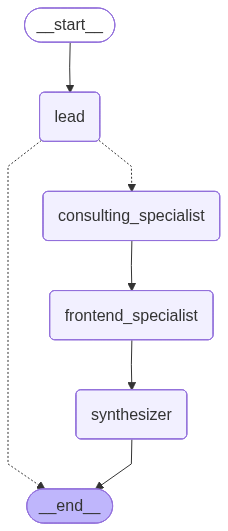

In [ ]:
from IPython.display import Image, display

display(Image(multi_agent_app.get_graph().draw_mermaid_png()))

# Run with live progress

The cell below uses `multi_agent_app.stream(...)` instead of `invoke(...)`.

That means you should now see live updates while the graph runs:

- lead-agent routing
- consulting search and report generation
- frontend tool calls and file creation
- final synthesis

In [ ]:
multi_agent_prompt = """
Create a consulting-grade launch recommendation for an AI study assistant.

You need to:
1. Research recent market signals or competitor moves.
2. Summarize the main user pain points.
3. Recommend a positioning angle.
4. Build a simple landing page for a learning platform, not a webpage version of the consulting report.
5. Use only the relevant strategic handoff from the report plus separate learning-platform UX guidance.
6. Produce both the consulting report and the frontend implementation.
""".strip()


def run_multi_agent_with_stream(prompt: str, thread_id: str = "multi-agent-hands-on-solution"):
    config = {
        "configurable": {"thread_id": thread_id},
        "recursion_limit": 6,
    }

    log_step("[run] starting graph stream")
    for event in multi_agent_app.stream(
        {
            "messages": [HumanMessage(content=prompt)],
            "request": prompt,
        },
        config=config,
        stream_mode="updates",
    ):
        print_agent_event("graph", event)

    final_state = multi_agent_app.get_state(config).values
    log_step("[run] graph complete")
    return final_state


multi_result = run_multi_agent_with_stream(multi_agent_prompt)

print(multi_result["final_answer"])

display(Markdown(multi_result["consulting_report"]))

for file_name in multi_result.get("frontend_files", []):
    language = "html"
    if file_name.endswith(".css"):
        language = "css"
    elif file_name.endswith(".js"):
        language = "javascript"
    display(Code(read_project_file.invoke({"path": file_name}), language=language))

[run] starting graph stream
[lead] deciding whether to use specialist pipeline
[lead] is_complex=True reason=The request combines strategic market research, product positioning, and a separate frontend build, so it requires the full specialist pipeline and synthesized ...
[graph:lead] update received
[consulting] starting consulting report generation
[consulting] planning search queries
[consulting] search 1: AI study assistant market signals 2024 competitor moves user pain points
[consulting] search 1 complete
[consulting] search 2: AI learning assistant competitors launch positioning student pain points
[consulting] search 2 complete
[consulting] search 3: study app AI assistant market trends competitors landing page best practices
[consulting] search 3 complete
[consulting] drafting consulting report
[consulting] report complete
[graph:consulting_specialist] update received
[frontend] preparing working directory
[frontend] extracting product and UX handoff from consulting report
[fr

# AI Study Assistant Launch Recommendation Report

## Executive Summary

The current AI study assistant market is shifting from “generic answer engine” toward “workflow-native, trust-first learning companion.” The clearest market signal is that incumbents and platform players are no longer treating study help as a standalone app category: Google has pushed math and homework help deeper into Search and mobile surfaces, OpenAI has packaged ChatGPT for universities through ChatGPT Edu, Khan Academy and Microsoft have moved toward district-level deployment, Apple has embedded math assistance into iPadOS, and Quizlet, Perplexity, and Chegg are all reworking their study propositions around AI. Taken together, these moves indicate that the market is consolidating around three value pools: on-demand problem solving, institution-ready tutoring, and citation-grounded study workflows.

User pain points are equally clear and consistent across sources. Students want to get unstuck quickly, but they do not trust uncited or fabricated outputs. Schools and parents want AI tools that support learning rather than shortcut it, yet policy ambiguity, privacy concerns, and detection anxiety remain real barriers to adoption. Price sensitivity is also a major issue: students are dealing with subscription fatigue, while teachers and districts need tools that fit existing LMS and administrative workflows. The result is a market in which product value is no longer defined only by model quality; it is defined by whether the assistant can demonstrate reliability, align to coursework, and reduce friction for both learners and institutions.

The recommended positioning is therefore **“the AI study assistant that helps students learn with confidence, not just finish faster.”** The winning angle is not a broad “all-in-one AI tutor,” but a focused promise: **step-by-step guidance grounded in a student’s own materials, with strong citation, privacy, and academic-integrity guardrails.** This positioning is directly responsive to the strongest market tensions in the evidence: students want speed, but schools want integrity; they want convenience, but they do not want hallucinations; they want access, but they are tired of paywalls. The product should translate that tension into a clean, trust-first message and a landing page that proves the value in one interaction.

## 1. Market Signals and Competitor Moves

The market signal in 2024–2026 is not simply that AI study tools are growing. It is that the category is becoming structurally more competitive because major platform companies are absorbing the use cases that used to belong to standalone education apps. Google pushed Circle to Search globally and expanded it to harder math and physics word problems with guided help; it also reinforced its homework-solving stack by making Photomath an official Google app in Play Store. OpenAI launched ChatGPT Edu for universities, with Arizona State University named as an early partner. Khan Academy made Khanmigo for Teachers free to U.S. educators and tied student tutoring to paid district partnerships. Apple normalized on-device math assistance with Math Notes in iPadOS 18. Chegg’s earnings communications framed AI search features and broad gen-AI adoption as headwinds. Perplexity moved toward education with Education Pro and academic search modes. Quizlet continued to position Q-Chat as a paid AI study feature. These are not isolated product updates; they are evidence that AI study assistance is moving into platform ecosystems, institution channels, and trust-centered workflows. [Google Search AI January 2024 update](https://blog.google/products-and-platforms/products/search/google-search-ai-january-2024-update/), [OpenAI ChatGPT Edu](https://openai.com/blog/introducing-chatgpt-edu/), [CNBC on Khan Academy and Microsoft](https://www.cnbc.com/2024/05/21/microsoft-khan-academy-launch-free-ai-assistant-for-all-us-teachers.html), [Time on Apple Math Notes](https://time.com/6987266/apple-ipad-calculator-app/), [Chegg investor relations](https://investor.chegg.com/Press-Releases/press-release-details/2024/Chegg-Reports-2024-Third-Quarter-Earnings/default.aspx), [Quizlet Q-Chat help](https://help.quizlet.com/hc/en-us/articles/18811152410125-Studying-with-Q-Chat), [Perplexity Education Pro](https://www.perplexity.ai/help-center/en/articles/12590157-what-is-education-pro).

Competitor moves reveal a second pattern: the market is splitting into distinct strategic archetypes. Google and Apple are embedding study help into their operating surfaces; OpenAI and Microsoft are packaging AI for education institutions; Khan Academy is leaning into pedagogy and district distribution; Quizlet and Chegg are trying to keep their legacy study audiences by adding AI layers; Perplexity is positioning around cited research workflows. In practical terms, this means “AI study assistant” is no longer a single competitive set. It is a contest between embedded convenience, institution-safe tooling, and specialized learning workflows. The strongest launch opportunity is therefore not to imitate generic chatbots, but to claim a narrow and defensible space where product trust and study utility are visibly better than the alternatives.

## 2. User Pain Points

The most persistent pain point is **trust**. The evidence repeatedly points to students needing to verify AI outputs, concern over citation fabrication, and broader skepticism about whether the answer is actually reliable. Tyton Partners’ learner research highlights verification behavior and non-trivial citation concerns, while the broader market brief points to a strong demand for “show your work + cite sources” as a default. This matters psychologically because students are not only buying accuracy; they are buying confidence. If the tool helps them complete work but cannot explain itself, it creates a second burden: double-checking. That additional verification step destroys the very time savings the assistant is supposed to create. [Tyton Partners](https://tytonpartners.com/listening-to-learners-2025/)

The second major pain point is **academic integrity and policy ambiguity**. EDUCAUSE found that privacy, ethics, and strategy gaps were slowing adoption in higher education, while institutions struggled with AI policy clarity and detection anxiety. Teachers and districts do not simply want a smarter chatbot; they want tools that scaffold thinking without encouraging plagiarism or bypassing learning. This creates a tension in the product experience: students want instant answers, but schools reward explanatory processes. A study assistant that is too permissive becomes risky for institutions; one that is too restrictive becomes frustrating for students. The product must therefore make the learning path feel faster than generic chat, while still preserving the “teach, don’t cheat” boundary. [EDUCAUSE April 2024 quick poll](https://er.educause.edu/articles/2024/4/educause-quickpoll-results-a-growing-need-for-generative-ai-strategy), [EDUCAUSE October 2024 quick poll](https://er.educause.edu/articles/2024/10/educause-quickpoll-results-advancing-analytics), [WLWT on guardrails](https://www.wlwt.com/article/reading-community-city-schools-pilot-new-ai-program/61922604)

A third issue is **privacy and cost**. Campus leaders flagged privacy as a top risk, and students face subscription fatigue because core study functionality is often locked behind paid tiers. Quizlet’s Q-Chat is a paid feature, while Perplexity’s education plans and other student pricing models show that the market is normalizing monetization, but not necessarily user delight. The resulting behavioral pattern is clear: students are willing to try AI tools, but they resist lock-in, opaque billing, and data-risk ambiguity. That means price and privacy are not just legal/commercial details; they are conversion levers. If the product cannot communicate “private by design” and “worth paying for,” it will lose both trust and retention. [EDUCAUSE](https://er.educause.edu/articles/2024/10/educause-quickpoll-results-advancing-analytics), [Quizlet Q-Chat](https://help.quizlet.com/hc/en-us/articles/18811152410125-Studying-with-Q-Chat), [Perplexity Education Pro](https://www.perplexity.ai/help-center/en/articles/12590157-what-is-education-pro)

Finally, there is a very practical workflow pain point: **generic help is not course-aligned help**. Students need explanations that match their syllabus, textbook, and teacher expectations. The provided research consistently suggests that the highest-value tools are those that can ingest notes, PDFs, and course materials, then turn them into step-by-step guidance, flashcards, quizzes, or adaptive study plans. This is the difference between an answer engine and a study companion. The former is broad and cheap to copy; the latter is tied to user context and learning outcomes. That distinction should drive both product design and launch messaging.

## 3. Positioning Recommendation

The recommended positioning is:

**“Learn faster with an AI coach that knows your materials, shows every step, and keeps you honest.”**

This position has three strategic advantages. First, it directly addresses the strongest user pain point: trust. “Shows every step” and “knows your materials” are tangible claims that signal groundedness, not just intelligence. Second, it resolves the market’s central tension between speed and integrity. The phrase “keeps you honest” communicates that the product is not a cheat engine; it is a learning tool with guardrails. Third, it creates a clearer differentiation against both generic chatbots and point-solvers. Generic chatbots are broad but ungrounded; point-solvers are narrow but often shallow in pedagogy; institutional tools are trusted but can be cumbersome. The proposed positioning sits between these extremes.

The best secondary angle is **course-aligned learning**. Rather than saying the product helps with “all subjects,” the launch should emphasize that it works with the user’s notes, textbook pages, slides, or syllabus. That is where the market is heading, and it is where the strongest proof of value exists. The recommendation is to lead with a promise of “step-by-step help grounded in your class materials,” then support that promise with a visible flow: upload or snap → get guided explanation → check understanding. This is materially stronger than abstract claims about AI capability because it maps directly to how students actually evaluate study tools.

For institutional buyers, the same positioning can be translated into a school-safe version: **“An AI study coach that supports learning, respects classroom policy, and offers admin-ready controls.”** That framing is important because districts and educators are increasingly part of the market. However, the launch should not split the core message. The product should maintain one primary identity — student learning with confidence — and then adapt proof points for teachers, parents, or schools.

The core strategic implication is that the brand should **avoid the language of “answers”**. The market is crowded with answer engines, and that language invites both commoditization and integrity concerns. Instead, the brand should own the language of **guidance, grounding, and learning progression**. That is the most defensible place to launch because it aligns with current market movements, reduces adoption friction, and supports a cleaner trust narrative.

## 4. Product and Launch Implications

The launch should be optimized around one simple product truth: **students convert when they can test the assistant immediately, without giving up trust or privacy.** That means the landing page should not read like a consulting report and should not over-explain the market. It should behave like a conversion page for a learning platform.

### Recommended landing page structure

**Hero section**
- Headline: **“Get unstuck faster — learn it, don’t just get the answer.”**
- Subheadline: “Upload your notes or snap a problem. Get step-by-step help, citations, and guided explanations that match your class materials.”
- Primary CTA: **“Try it on your notes”**
- Secondary CTA: **“Watch 60-sec demo”**
- Trust strip: “Private by design” / “School-friendly” / “Built to teach, not cheat”

This is the right first-screen message because it answers the three buyer questions immediately: Will it help me? Is it allowed? Is my data safe?

**How it works**
1. Upload notes, PDFs, slides, or a homework problem
2. Get guided hints and step-by-step explanations
3. Check understanding with practice questions or a quick quiz

This section should be visual and product-led, not text-heavy. The value must be obvious in under 10 seconds.

**Why it’s different**
- Grounded in your own materials
- Step-by-step, not shortcut answers
- Designed with academic integrity in mind
- Transparent privacy controls

These are not feature claims; they are conversion claims. They should reduce anxiety and improve trial intent.

**Plans**
- Free trial or free tier with usage caps
- Student plan with transparent pricing
- School / district plan with admin controls and rostering

The pricing logic should reflect the evidence of subscription fatigue. Transparency matters as much as low price.

### Product implications

1. **Build around verifiable guidance**
   The strongest product differentiator is not model novelty; it is verifiability. Inline citations, source checking, and a clear “show your work” experience should be default, especially for STEM and research tasks. This directly addresses the most cited trust pain points.

2. **Use course materials as the core data advantage**
   Syllabus import, note upload, and document grounding should be central. This moves the product away from generic competition and into personalized study workflow territory.

3. **Add guardrails, not friction**
   The product should prefer hints, scaffolds, and explanation ladders before revealing solutions. The goal is to feel helpful without crossing into “do it for me.” This is especially important for school adoption.

4. **Keep the first-run experience friction-light**
   The page should allow a user to try the assistant before account creation if possible. The market guidance suggests that low-friction try-before-signup flows are essential in this category.

5. **Make privacy and integrity visible**
   Privacy language should be plain English. If the product does not sell data or use ads, say so. If there are school controls, show them. These are not compliance footnotes; they are conversion assets.

### Simple frontend implementation

Below is a concise landing page implementation for a learning platform, not a consulting-report webpage.

```html
<!doctype html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>StudyCo — Learn Faster with an AI Coach</title>
    <meta
      name="description"
      content="Upload notes or snap a problem. Get step-by-step help, citations, and guided explanations that match your class materials."
    />
    <style>
      :root {
        --bg: #0b1020;
        --panel: #121a33;
        --card: #182345;
        --text: #f4f7ff;
        --muted: #aeb9da;
        --brand: #6ea8fe;
        --brand2: #7cf0c5;
        --border: rgba(255,255,255,0.10);
        --shadow: 0 20px 60px rgba(0,0,0,0.28);
      }
      * { box-sizing: border-box; }
      body {
        margin: 0;
        font-family: Inter, ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
        background: radial-gradient(circle at top, #152044 0%, var(--bg) 60%);
        color: var(--text);
        line-height: 1.5;
      }
      .wrap {
        max-width: 1180px;
        margin: 0 auto;
        padding: 28px 20px 60px;
      }
      .nav {
        display: flex;
        align-items: center;
        justify-content: space-between;
        gap: 16px;
        margin-bottom: 72px;
      }
      .brand {
        font-weight: 800;
        letter-spacing: 0.2px;
        font-size: 20px;
      }
      .nav a {
        color: var(--muted);
        text-decoration: none;
        margin-left: 18px;
        font-size: 14px;
      }
      .hero {
        display: grid;
        grid-template-columns: 1.05fr 0.95fr;
        gap: 28px;
        align-items: center;
      }
      h1 {
        font-size: clamp(40px, 6vw, 68px);
        line-height: 0.98;
        margin: 0 0 18px;
        letter-spacing: -0.04em;
      }
      .sub {
        font-size: 18px;
        color: var(--muted);
        max-width: 54ch;
        margin-bottom: 28px;
      }
      .cta-row {
        display: flex;
        flex-wrap: wrap;
        gap: 12px;
        margin-bottom: 18px;
      }
      .btn {
        appearance: none;
        border: 0;
        border-radius: 14px;
        padding: 14px 20px;
        font-weight: 700;
        cursor: pointer;
        font-size: 15px;
      }
      .btn.primary {
        background: linear-gradient(135deg, var(--brand), var(--brand2));
        color: #08101f;
      }
      .btn.secondary {
        background: rgba(255,255,255,0.06);
        color: var(--text);
        border: 1px solid var(--border);
      }
      .trust {
        display: flex;
        flex-wrap: wrap;
        gap: 10px;
        color: var(--muted);
        font-size: 13px;
      }
      .pill {
        padding: 8px 12px;
        border: 1px solid var(--border);
        border-radius: 999px;
        background: rgba(255,255,255,0.04);
      }
      .mock {
        background: linear-gradient(180deg, rgba(255,255,255,0.08), rgba(255,255,255,0.03));
        border: 1px solid var(--border);
        border-radius: 24px;
        box-shadow: var(--shadow);
        padding: 18px;
      }
      .mock-top {
        display: flex;
        justify-content: space-between;
        gap: 12px;
        margin-bottom: 16px;
        color: var(--muted);
        font-size: 13px;
      }
      .upload {
        border: 1px dashed rgba(255,255,255,0.18);
        border-radius: 18px;
        padding: 20px;
        background: rgba(0,0,0,0.12);
        margin-bottom: 16px;
      }
      .upload strong { display: block; margin-bottom: 6px; }
      .chat {
        display: grid;
        gap: 12px;
      }
      .bubble {
        padding: 14px 16px;
        border-radius: 16px;
        max-width: 92%;
      }
      .bubble.user {
        justify-self: end;
        background: rgba(110,168,254,0.18);
        border: 1px solid rgba(110,168,254,0.25);
      }
      .bubble.ai {
        background: rgba(124,240,197,0.10);
        border: 1px solid rgba(124,240,197,0.18);
      }
      .grid {
        margin-top: 84px;
        display: grid;
        grid-template-columns: repeat(3, 1fr);
        gap: 16px;
      }
      .card {
        background: rgba(255,255,255,0.05);
        border: 1px solid var(--border);
        border-radius: 20px;
        padding: 22px;
      }
      .card h3 { margin: 0 0 10px; font-size: 18px; }
      .card p { margin: 0; color: var(--muted); }
      .section-title {
        margin: 76px 0 18px;
        font-size: 28px;
        letter-spacing: -0.03em;
      }
      .steps {
        display: grid;
        grid-template-columns: repeat(3, 1fr);
        gap: 16px;
      }
      .step {
        border-radius: 18px;
        background: rgba(255,255,255,0.04);
        border: 1px solid var(--border);
        padding: 18px;
      }
      .step-num {
        width: 34px;
        height: 34px;
        border-radius: 999px;
        display: grid;
        place-items: center;
        font-weight: 800;
        background: rgba(110,168,254,0.18);
        margin-bottom: 12px;
      }
      .pricing {
        display: grid;
        grid-template-columns: repeat(3, 1fr);
        gap: 16px;
      }
      .price {
        background: rgba(255,255,255,0.05);
        border: 1px solid var(--border);
        border-radius: 20px;
        padding: 22px;
      }
      .price.featured {
        outline: 2px solid rgba(124,240,197,0.35);
        transform: translateY(-4px);
      }
      .amt {
        font-size: 34px;
        font-weight: 800;
        margin: 10px 0;
      }
      footer {
        margin-top: 56px;
        color: var(--muted);
        font-size: 13px;
        display: flex;
        justify-content: space-between;
        gap: 16px;
        flex-wrap: wrap;
      }
      @media (max-width: 900px) {
        .hero, .grid, .steps, .pricing {
          grid-template-columns: 1fr;
        }
        .nav { margin-bottom: 40px; }
      }
    </style>
  </head>
  <body>
    <div class="wrap">
      <header class="nav">
        <div class="brand">StudyCo</div>
        <nav>
          <a href="#how">How it works</a>
          <a href="#why">Why StudyCo</a>
          <a href="#plans">Plans</a>
        </nav>
      </header>

      <main class="hero">
        <div>
          <h1>Get unstuck faster — learn it, don’t just get the answer.</h1>
          <p class="sub">
            Upload your notes or snap a problem. Get step-by-step help, citations,
            and guided explanations that match your class materials.
          </p>

          <div class="cta-row">
            <button class="btn primary">Try it on your notes</button>
            <button class="btn secondary">Watch 60-sec demo</button>
          </div>

          <div class="trust">
            <span class="pill">Private by design</span>
            <span class="pill">Step-by-step guidance</span>
            <span class="pill">Built to teach, not cheat</span>
          </div>
        </div>

        <div class="mock">
          <div class="mock-top">
            <span>AI Coach Preview</span>
            <span>Math • Science • Writing</span>
          </div>
          <div class="upload">
            <strong>Upload class notes or a homework problem</strong>
            <span>Drag & drop PDF, image, or paste text</span>
          </div>
          <div class="chat">
            <div class="bubble user">Can you help me solve this without giving away the answer?</div>
            <div class="bubble ai">
              Absolutely. Let’s break it into steps. First, identify the given values,
              then choose the formula that matches the problem. I’ll cite the exact
              part of your notes as we go.
            </div>
          </div>
        </div>
      </main>

      <section class="grid" id="why">
        <div class="card">
          <h3>Grounded in your materials</h3>
          <p>Use your notes, slides, PDFs, and syllabus so help stays course-aligned.</p>
        </div>
        <div class="card">
          <h3>Shows every step</h3>
          <p>Get hints, explanations, and checks for understanding instead of shortcut answers.</p>
        </div>
        <div class="card">
          <h3>Privacy and integrity first</h3>
          <p>Clear study controls that support academic honesty and reduce policy anxiety.</p>
        </div>
      </section>

      <section id="how">
        <h2 class="section-title">How it works</h2>
        <div class="steps">
          <div class="step">
            <div class="step-num">1</div>
            <h3>Upload</h3>
            <p>Bring in notes, PDFs, slides, or a photo of a problem.</p>
          </div>
          <div class="step">
            <div class="step-num">2</div>
            <h3>Coach</h3>
            <p>Get guided prompts, step-by-step help, and source-backed explanations.</p>
          </div>
          <div class="step">
            <div class="step-num">3</div>
            <h3>Check</h3>
            <p>Practice with quick quizzes and see whether you actually understand it.</p>
          </div>
        </div>
      </section>

      <section id="plans">
        <h2 class="section-title">Simple plans</h2>
        <div class="pricing">
          <div class="price">
            <h3>Free</h3>
            <div class="amt">$0</div>
            <p>Try the assistant with limited daily usage.</p>
          </div>
          <div class="price featured">
            <h3>Student</h3>
            <div class="amt">$9/mo</div>
            <p>Unlimited guided study, citations, and practice tools.</p>
          </div>
          <div class="price">
            <h3>School</h3>
            <div class="amt">Custom</div>
            <p>Admin controls, rostering, and classroom-safe workflows.</p>
          </div>
        </div>
      </section>

      <footer>
        <span>© 2026 StudyCo</span>
        <span>FERPA/COPPA-aware • No ads • Data deletion controls</span>
      </footer>
    </div>
  </body>
</html>
```

## 5. References

[1] Google. Google Search AI January 2024 update[EB/OL]. https://blog.google/products-and-platforms/products/search/google-search-ai-january-2024-update/  
[2] OpenAI. Introducing ChatGPT Edu[EB/OL]. https://openai.com/blog/introducing-chatgpt-edu/  
[3] CNBC. Microsoft and Khan Academy launch free AI assistant for all U.S. teachers[EB/OL]. https://www.cnbc.com/2024/05/21/microsoft-khan-academy-launch-free-ai-assistant-for-all-us-teachers.html  
[4] Time. Apple’s iPad Calculator app and Math Notes coverage[EB/OL]. https://time.com/6987266/apple-ipad-calculator-app/  
[5] Chegg Investor Relations. Chegg Reports 2024 Third Quarter Earnings[EB/OL]. https://investor.chegg.com/Press-Releases/press-release-details/2024/Chegg-Reports-2024-Third-Quarter-Earnings/default.aspx  
[6] Quizlet Help Center. Studying with Q-Chat[EB/OL]. https://help.quizlet.com/hc/en-us/articles/18811152410125-Studying-with-Q-Chat  
[7] Perplexity Help Center. What is Education Pro[EB/OL]. https://www.perplexity.ai/help-center/en/articles/12590157-what-is-education-pro  
[8] Tyton Partners. Listening to Learners 2025[EB/OL]. https://tytonpartners.com/listening-to-learners-2025/  
[9] EDUCAUSE. QuickPoll Results: A Growing Need for Generative AI Strategy[EB/OL]. https://er.educause.edu/articles/2024/4/educause-quickpoll-results-a-growing-need-for-generative-ai-strategy  
[10] EDUCAUSE. QuickPoll Results: Advancing Analytics[EB/OL]. https://er.educause.edu/articles/2024/10/educause-quickpoll-results-advancing-analytics  
[11] WLWT. Reading Community City Schools pilot new AI program[EB/OL]. https://www.wlwt.com/article/reading-community-city-schools-pilot-new-ai-program/61922604

const observer = new IntersectionObserver((entries) => {
  entries.forEach((entry) => {
    if (entry.isIntersecting) entry.target.classList.add('is-visible');
  });
}, { threshold: 0.15 });

document.querySelectorAll('.reveal').forEach((el) => observer.observe(el));

<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>StudyCo — AI study coach for notes, PDFs, and homework</title>
  <meta name="description" content="StudyCo helps students learn faster with step-by-step guidance grounded in their own materials, with citations and academic-integrity guardrails." />
  <link rel="preconnect" href="https://fonts.googleapis.com">
  <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
  <link href="https://fonts.googleapis.com/css2?family=Fraunces:opsz,wght@9..144,500;9..144,700&family=IBM+Plex+Sans:wght@400;500;600;700&display=swap" rel="stylesheet">
  <link rel="stylesheet" href="styles.css" />
</head>
<body>
  <div class="page-shell">
    <div class="grain"></div>
    <header class="topbar">
      <div class="brand">
        <span class="brand-mark">S</span>
        <div>
          <div class="brand-name">StudyCo</div>
          <div class="brand-sub">School-safe AI study support</div>
        </div>
      </div>
      <nav class="topnav" aria-label="Primary">
        <a href="#how-it-works">How it works</a>
        <a href="#trust">Trust</a>
        <a href="#pricing">Pricing</a>
      </nav>
    </header>

    <main>
      <section class="hero">
        <div class="hero-copy reveal">
          <p class="eyebrow">Step-by-step help from your own materials</p>
          <h1>Turn notes, PDFs, and slides into a coach that teaches — not just answers.</h1>
          <p class="lede">StudyCo helps students get unstuck fast with grounded explanations, citations, and guardrails that keep learning on track.</p>

          <div class="hero-actions">
            <a class="btn btn-primary" href="#demo">Try it on your notes</a>
            <a class="btn btn-secondary" href="#demo">Watch 60-sec demo</a>
          </div>

          <div class="microtrust">
            <span>No credit card</span>
            <span>Private by design</span>
            <span>Built to teach, not cheat</span>
          </div>
        </div>

        <div class="hero-visual reveal delay-1" id="demo" aria-label="Product demo mockup">
          <div class="device">
            <div class="device-top">
              <span></span><span></span><span></span>
            </div>
            <div class="upload-card">
              <div class="upload-chip">Upload notes.pdf</div>
              <div class="upload-chip muted">Chemistry slide deck</div>
              <div class="upload-chip muted">Snap a problem</div>
            </div>
            <div class="coach-panel">
              <div class="coach-head">
                <div>
                  <span class="label">StudyCo coach</span>
                  <h2>Why does this formula work?</h2>
                </div>
                <span class="status">Cited</span>
              </div>
              <div class="answer-card">
                <p>We’ll start with the idea in your notes, then show the steps using your professor’s vocabulary.</p>
                <ol>
                  <li>Identify the knowns and unknowns.</li>
                  <li>Match the method from page 12 of your handout.</li>
                  <li>Check the result against the example problem.</li>
                </ol>
                <div class="cite-row">
                  <span>Sources:</span>
                  <a href="javascript:void(0)">Lecture notes p.12</a>
                  <a href="javascript:void(0)">Textbook ch.4</a>
                </div>
              </div>
            </div>
          </div>
        </div>
      </section>

      <section class="trust-strip reveal delay-2" id="trust">
        <div>Private by design</div>
        <div>School-friendly controls</div>
        <div>Grounded in your materials</div>
        <div>Step-by-step guidance</div>
      </section>

      <section class="workflow">
        <div class="section-head reveal">
          <p class="eyebrow">A simple study flow</p>
    

:root{--bg:#f3efe7;--bg2:#e7dfd2;--ink:#14120f;--muted:#5f564a;--card:#fffaf2;--line:rgba(20,18,15,.12);--accent:#0f5c4a;--accent2:#c96b2c;--shadow:0 18px 60px rgba(20,18,15,.12);--radius:26px}*{box-sizing:border-box}html{scroll-behavior:smooth}body{margin:0;font-family:'IBM Plex Sans',system-ui,sans-serif;color:var(--ink);background:radial-gradient(circle at top left,#fff7ea 0,transparent 34%),linear-gradient(180deg,var(--bg),var(--bg2));min-height:100vh}.page-shell{position:relative;overflow:hidden}.grain{pointer-events:none;position:fixed;inset:0;opacity:.07;background-image:url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' width='140' height='140' viewBox='0 0 140 140'%3E%3Cfilter id='n'%3E%3CfeTurbulence type='fractalNoise' baseFrequency='.85' numOctaves='2' stitchTiles='stitch'/%3E%3C/filter%3E%3Crect width='140' height='140' filter='url(%23n)' opacity='.5'/%3E%3C/svg%3E")}.topbar,.hero,.workflow,.proof-grid,.cta-panel,.footer{width:min(1160px,calc(100% - 32px));margin:0 auto}.topbar{display:flex;justify-content:space-between;align-items:center;padding:22px 0}.brand{display:flex;align-items:center;gap:12px}.brand-mark{width:42px;height:42px;border-radius:14px;display:grid;place-items:center;background:linear-gradient(135deg,var(--ink),#423b31);color:#fff7ea;font-family:'Fraunces',serif;font-size:1.25rem}.brand-name{font-weight:700;letter-spacing:.02em}.brand-sub,.topnav a,.microtrust,.quote span,.footer{color:var(--muted);font-size:.92rem}.topnav{display:flex;gap:22px}.topnav a,.signature{color:inherit;text-decoration:none}.hero{display:grid;grid-template-columns:1.05fr .95fr;gap:28px;align-items:center;padding:36px 0 24px}.eyebrow{text-transform:uppercase;letter-spacing:.18em;font-size:.76rem;color:var(--accent);font-weight:700}.hero h1,.section-head h2,.proof-card h2,.cta-panel h2{font-family:'Fraunces',serif;line-height:.96;letter-spacing:-.03em;margin:.15em 0 .3em}.hero h1{font-size:clamp(3rem,6vw,5.9rem);max-width:12ch}.lede{font-size:1.12rem;line-height:1.7;max-width:58ch;color:var(--muted)}.hero-actions{display:flex;gap:14px;flex-wrap:wrap;margin:28px 0 16px}.btn{display:inline-flex;align-items:center;justify-content:center;padding:15px 20px;border-radius:999px;text-decoration:none;font-weight:700;border:1px solid transparent;transition:.24s ease;box-shadow:0 0 0 rgba(0,0,0,0)}.btn:hover{transform:translateY(-2px);box-shadow:var(--shadow)}.btn-primary{background:var(--ink);color:#fff7ea}.btn-secondary{background:rgba(255,255,255,.38);color:var(--ink);border-color:var(--line)}.microtrust{display:flex;gap:16px;flex-wrap:wrap}.microtrust span,.trust-strip div{padding:10px 14px;border:1px solid var(--line);border-radius:999px;background:rgba(255,250,242,.55);backdrop-filter:blur(10px)}.hero-visual{display:flex;justify-content:center}.device{width:min(100%,520px);background:linear-gradient(180deg,#241f1a,#161310);color:#f7efe4;border-radius:34px;padding:14px;box-shadow:var(--shadow);border:1px solid rgba(255,255,255,.08);transform:rotate(2deg)}.device-top{display:flex;gap:7px;padding:4px 2px 12px}.device-top span{width:9px;height:9px;border-radius:50%;background:rgba(255,255,255,.24)}.upload-card,.coach-panel{background:rgba(255,250,242,.06);border:1px solid rgba(255,255,255,.1);border-radius:24px;padding:16px}.upload-card{display:flex;gap:10px;flex-wrap:wrap;margin-bottom:14px}.upload-chip{padding:10px 12px;border-radius:999px;background:#f4e7d1;color:#241f1a;font-weight:600;font-size:.92rem}.upload-chip.muted{background:rgba(255,255,255,.08);color:#f7efe4;font-weight:500}.coach-head{display:flex;justify-content:space-between;gap:18px;align-items:flex-start}.label,.status{font-size:.74rem;text-transform:uppercase;letter-spacing:.18em}.status{color:#ffcb84}.coach-panel h2{margin:.18rem 0 0;font-size:1.55rem;line-height:1.1}.answer-card{margin-top:14px;background:#f7efe4;color:#1a1814;border-radius:22px;padding:18px}.answer-card p{margin-top:0;line-height:1.6}.answer-card ol{margin:0 0 14px 18px;line-hei

In [ ]:
# Optional: render the generated landing page preview in the notebook
if "index.html" in multi_result.get("frontend_files", []):
    html = read_project_file.invoke({"path": "index.html"})
    css = read_project_file.invoke({"path": "styles.css"}) if "styles.css" in multi_result.get("frontend_files", []) else ""
    js = read_project_file.invoke({"path": "app.js"}) if "app.js" in multi_result.get("frontend_files", []) else ""
    preview = f"<style>{css}</style>{html}<script>{js}</script>"
    display(HTML(preview))

# Optional extensions

- Add a reviewer agent after the synthesizer.
- Add a guardrail that skips web research for obviously simple prompts.
- Split the consulting step into separate market and user-insight nodes.
- Turn the frontend brief into a real wireframe or landing-page prototype in a follow-up notebook.